## Keras Tuner
- KerasTuner is an easy-to-use, scalable hyperparameter optimization framework that solves the pain points of hyperparameter search. Easily configure your search space with a define-by-run syntax, then leverage one of the available search algorithms to find the best hyperparameter values for your models. KerasTuner comes with Bayesian Optimization, Hyperband, and Random Search algorithms built-in, and is also designed to be easy for researchers to extend in order to experiment with new search algorithms.

--------------------

## Pima Indians Diabetes
-------------------------------------------

### About Dataset
- This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.
- The datasets consists of several medical predictor variables and one target variable, Outcome. Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

### Import required libraries

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l1, l2, l1_l2
from keras.callbacks import EarlyStopping
import keras_tuner as kt
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import pickle

In [3]:
df = pd.read_csv("../../../datasets/diabetes.csv")
df.shape

(768, 9)

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
121,6,111,64,39,0,34.2,0.260,24,0
16,0,118,84,47,230,45.8,0.551,31,1
479,4,132,86,31,0,28.0,0.419,63,0
99,1,122,90,51,220,49.7,0.325,31,1
165,6,104,74,18,156,29.9,0.722,41,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.corr()["Outcome"]

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

In [10]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
model = Sequential()

model.add(Dense(32, activation="relu", input_dim=X_train.shape[1]))
model.add(Dense(1, activation="sigmoid"))

model.summary()

C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [15]:
history = model.fit(X_train, y_train ,epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.6482 - loss: 0.6712 - val_accuracy: 0.6753 - val_loss: 0.6033
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6824 - loss: 0.6207 - val_accuracy: 0.7403 - val_loss: 0.5664
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7199 - loss: 0.5830 - val_accuracy: 0.7468 - val_loss: 0.5449
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7264 - loss: 0.5569 - val_accuracy: 0.7597 - val_loss: 0.5290
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7476 - loss: 0.5369 - val_accuracy: 0.7727 - val_loss: 0.5175
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7638 - loss: 0.5204 - val_accuracy: 0.7922 - val_loss: 0.5091
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7752 - loss: 0.5078 - val_accuracy: 0.7857 - val_loss: 0.5029
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7834 - loss: 0.4979 - val_accuracy: 0.7857 - v

### Keras Tuner - (Hyper Parameter Tuning)

- 1\) how to select appropriate optimizer
- 2\) number of nodes in layer
- 3\) how to select number of layers
- 4\) all in one model

In [16]:
# pip install keras-tuner
# pip install tensorboard

In [19]:
def build_model(hp):
    model = Sequential()

    model.add(Dense(32, activation="relu", input_dim=X_train.shape[1]))    
    model.add(Dense(1, activation="sigmoid"))

    optimizer = hp.Choice("optimizer", values = ["adam", "sgd", "rmsprop", "adadelta"])
    model.compile(optimizer = optimizer, loss="binary_crossentropy", metrics=["accuracy"])

    return model

In [20]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    directory="mydir",
    project_name="optimizer"
)

In [21]:
tuner.search(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Trial 4 Complete [00h 00m 01s]
val_accuracy: 0.6233766078948975

Best val_accuracy So Far: 0.7597402334213257
Total elapsed time: 00h 00m 06s


In [22]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'rmsprop'}

In [23]:
model = tuner.get_best_models(num_models=1)[0]

C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(X_train, y_train, batch_size=32, epochs=100, initial_epoch=6, validation_data=(X_test, y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7573 - loss: 0.4994 - val_accuracy: 0.7662 - val_loss: 0.5376
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7622 - loss: 0.4864 - val_accuracy: 0.7662 - val_loss: 0.5329
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7687 - loss: 0.4778 - val_accuracy: 0.7727 - val_loss: 0.5293
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7736 - loss: 0.4711 - val_accuracy: 0.7662 - val_loss: 0.5281
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7720 - loss: 0.4652 - val_accuracy: 0.7662 - val_loss: 0.5270
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7785 - loss: 0.4602 - val_accuracy: 0.7727 - val_loss: 0.5268
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7834 - loss: 0.4562 - val_accuracy: 0.7727 - val_loss: 0.5265
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7834 - loss: 0.4533 - val_accuracy: 0.779

In [26]:
def build_model(hp):
    model = Sequential()

    units = hp.Int("units", min_value=8, max_value=128)

    model.add(Dense(units=units, activation="relu", input_dim=X_train.shape[1]))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    return model

In [27]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    directory="mydir",
    project_name="layer_1 units"
)

In [28]:
tuner.search(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Trial 5 Complete [00h 00m 01s]
val_accuracy: 0.7922077775001526

Best val_accuracy So Far: 0.7922077775001526
Total elapsed time: 00h 00m 06s


In [29]:
tuner.get_best_hyperparameters()[0].values

{'units': 112}

In [30]:
model = tuner.get_best_models(num_models=1)[0]

C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 112)            │         1,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           113 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(X_train, y_train, batch_size=32, epochs=100, initial_epoch=6, validation_data=(X_test, y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7801 - loss: 0.4712 - val_accuracy: 0.7987 - val_loss: 0.5047
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7834 - loss: 0.4611 - val_accuracy: 0.7792 - val_loss: 0.5072
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7866 - loss: 0.4543 - val_accuracy: 0.7857 - val_loss: 0.5094
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7883 - loss: 0.4505 - val_accuracy: 0.7922 - val_loss: 0.5125
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7915 - loss: 0.4469 - val_accuracy: 0.7922 - val_loss: 0.5102
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7883 - loss: 0.4448 - val_accuracy: 0.7987 - val_loss: 0.5080
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7866 - loss: 0.4425 - val_accuracy: 0.7662 - val_loss: 0.5105
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7866 - loss: 0.4405 - val_accuracy: 0.779

In [33]:
def build_model(hp):
    model = Sequential()

    model.add(Dense(36, activation="relu", input_dim=X_train.shape[1]))

    for i in range(hp.Int("num_layers", min_value=1, max_value=10)):
        model.add(Dense(36, activation="relu"))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    return model

In [34]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    directory="mydir",
    project_name="num_of_layers"
)

In [35]:
tuner.search(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Trial 5 Complete [00h 00m 02s]
val_accuracy: 0.7727272510528564

Best val_accuracy So Far: 0.7792207598686218
Total elapsed time: 00h 00m 09s


In [36]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 4}

In [37]:
model = tuner.get_best_models(num_models=1)[0]

C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [38]:
model.fit(
    X_train,
    y_train,
    epochs=100,
    initial_epoch=6,
    validation_data=(X_test,y_test)
)

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7850 - loss: 0.4677 - val_accuracy: 0.7662 - val_loss: 0.5172
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7866 - loss: 0.4516 - val_accuracy: 0.7662 - val_loss: 0.5188
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8029 - loss: 0.4435 - val_accuracy: 0.7662 - val_loss: 0.5189
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7883 - loss: 0.4356 - val_accuracy: 0.7662 - val_loss: 0.5226
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7980 - loss: 0.4300 - val_accuracy: 0.7403 - val_loss: 0.5307
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7997 - loss: 0.4257 - val_accuracy: 0.7468 - val_loss: 0.5308
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8046 - loss: 0.4206 - val_accuracy: 0.7403 - val_loss: 0.5284
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8046 - loss: 0.4171 - val_accuracy: 0.746

In [9]:
df = pd.read_csv("../../../datasets/diabetes.csv")
df.shape

(768, 9)

In [10]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

In [12]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))
class_weights

{np.int64(0): np.float64(0.7675), np.int64(1): np.float64(1.4345794392523366)}

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [170]:
def build_model(hp):
    model = Sequential()


    counter = 0
    for i in range(hp.Int("num_layers", min_value=5, max_value=10)):
        if counter == 0:
            model.add(
                Dense(
                    hp.Int("units" + str(i), min_value=8, max_value=128, step=8),
                    activation = hp.Choice("activation" + str(i), values=["relu", "elu", "selu"]),
                    input_dim = X_train.shape[1]
                ))

            model.add(
                Dropout(
                    hp.Choice("dropout" + str(i), values=[0.1,0.2,0.3,0.4,0.5])
                )
            )
        else:
            model.add(
                Dense(
                    hp.Int("units" + str(i), min_value=8, max_value=128, step=8),
                    activation = hp.Choice("activation" + str(i), values=["relu", "elu", "selu"])
                ))

            model.add(
                Dropout(
                    hp.Choice("dropout" + str(i), values=[0.1,0.2,0.3,0.4,0.5])
                )
            )
            
        counter += 1

    model.add(Dense(1, activation="sigmoid"))

    model.compile(optimizer=hp.Choice("optimizer", values=["rmsprop", "adam", "sgd", "nadam", "adadelta"]),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    
    return model

In [171]:
# def build_model(hp):
#     model = Sequential()

#     # Tune number of layers
#     num_layers = hp.Int("num_layers", min_value=5, max_value=10)

#     for i in range(num_layers):

#         units = hp.Int(f'units_{i}', min_value=8, max_value=256, step=16)

#         activation = hp.Choice(f'activation_{i}', values=["relu", "elu", "selu"])

#         # Regularization
#         reg_choice = hp.Choice(f'reg_{i}', ["none", "l1", "l2", "l1_l2"])
#         if reg_choice == "l1":
#             reg = l1(hp.Float(f"l1_{i}", 1e-5, 1e-2, sampling="log"))
#         elif reg_choice == "l2":
#             reg = l2(hp.Float(f"l2_{i}", 1e-5, 1e-2, sampling="log"))
#         elif reg_choice == "l1_l2":
#             reg = l1_l2(
#                 l1=hp.Float(f"l1l2_l1_{i}", 1e-5, 1e-2, sampling="log"),
#                 l2=hp.Float(f"l1l2_l2_{i}", 1e-5, 1e-2, sampling="log")
#             )
#         else:
#             reg = None

#         # First layer needs input_dim
#         if i == 0:
#             model.add(Dense(units, activation=activation,
#                             kernel_regularizer=reg,
#                             input_dim=X_train.shape[1]))
#         else:
#             model.add(Dense(units, activation=activation,
#                             kernel_regularizer=reg))

#         # Optional BatchNorm
#         if hp.Boolean(f'batch_norm_{i}'):
#             model.add(BatchNormalization())

#         # Dropout
#         model.add(Dropout(
#             hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)
#         ))

#     # Output layer
#     model.add(Dense(1, activation="sigmoid"))

#     # Optimizer tuning with learning rate
#     optimizer_choice = hp.Choice("optimizer", ["adam", "rmsprop", "sgd", "nadam"])

#     learning_rate = hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")

#     if optimizer_choice == "adam":
#         optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
#     elif optimizer_choice == "rmsprop":
#         optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
#     elif optimizer_choice == "sgd":
#         optimizer = tf.keras.optimizers.SGD(
#             learning_rate=learning_rate,
#             momentum=hp.Float("momentum", 0.0, 0.9, step=0.1)
#         )
#     elif optimizer_choice == "nadam":
#         optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)

#     model.compile(
#         optimizer=optimizer,
#         loss=hp.Choice("loss", ["binary_crossentropy"]),
#         metrics=["accuracy"]
#     )

#     return model

In [172]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=30,
    directory="mydir",
    project_name="all_tuning_model_2"
)

C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [173]:
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

In [174]:
tuner.search(
    X_train,
    y_train,
    epochs=30, 
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weights
)

Trial 30 Complete [00h 00m 08s]
val_accuracy: 0.7532467246055603

Best val_accuracy So Far: 0.8051947951316833
Total elapsed time: 00h 04m 24s


In [175]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 8,
 'units0': 112,
 'activation0': 'relu',
 'dropout0': 0.3,
 'units1': 16,
 'activation1': 'elu',
 'dropout1': 0.2,
 'units2': 80,
 'activation2': 'elu',
 'dropout2': 0.1,
 'units3': 32,
 'activation3': 'relu',
 'dropout3': 0.4,
 'units4': 40,
 'activation4': 'elu',
 'dropout4': 0.4,
 'optimizer': 'adam',
 'units5': 24,
 'activation5': 'elu',
 'dropout5': 0.1,
 'units6': 80,
 'activation6': 'relu',
 'dropout6': 0.1,
 'units7': 24,
 'activation7': 'relu',
 'dropout7': 0.4,
 'units8': 80,
 'activation8': 'relu',
 'dropout8': 0.1}

In [176]:
model = tuner.get_best_models(num_models=1)[0]

C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [177]:
history = model.fit(X_train, y_train, epochs=100, initial_epoch=30, validation_data=(X_test, y_test), callbacks=[early_stop], class_weight=class_weights)

Epoch 31/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6368 - loss: 0.6492 - val_accuracy: 0.7662 - val_loss: 0.5504
Epoch 32/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7068 - loss: 0.5794 - val_accuracy: 0.7338 - val_loss: 0.5279
Epoch 33/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7068 - loss: 0.5848 - val_accuracy: 0.7468 - val_loss: 0.5092
Epoch 34/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7117 - loss: 0.5644 - val_accuracy: 0.7208 - val_loss: 0.5257
Epoch 35/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7296 - loss: 0.5265 - val_accuracy: 0.7338 - val_loss: 0.5282
Epoch 36/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7231 - loss: 0.5456 - val_accuracy: 0.6753 - val_loss: 0.5602
Epoch 37/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7410 - loss: 0.5252 - val_accuracy: 0.7078 - val_loss: 0.5411
Epoch 38/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7068 - loss: 0.5452 - val_accuracy: 0

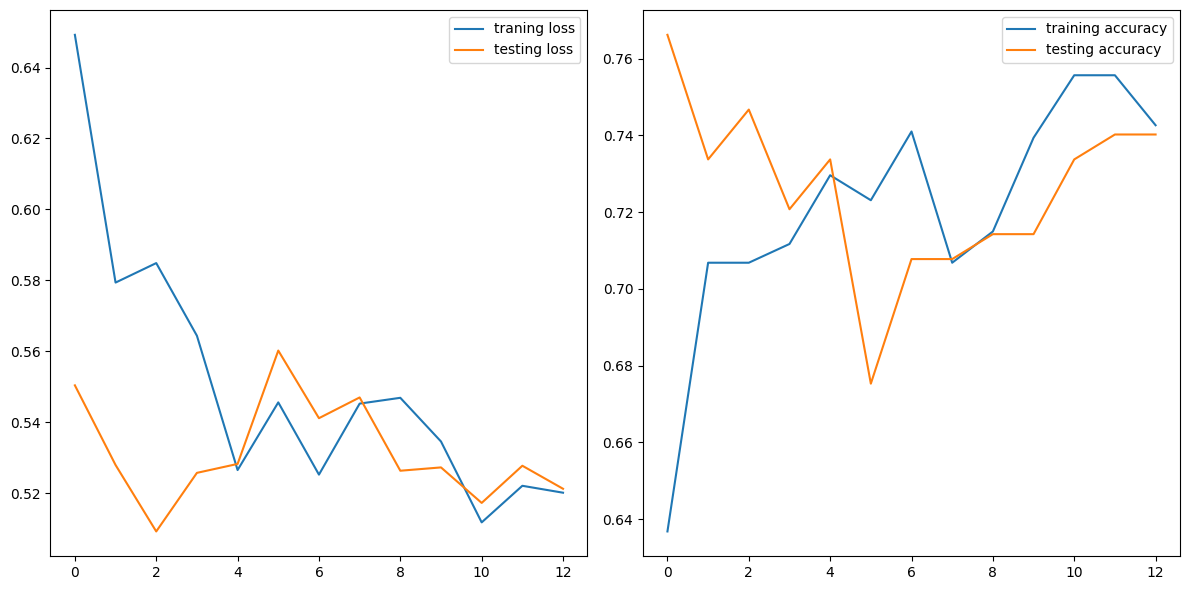

In [178]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

sns.lineplot(history.history["loss"], label="traning loss", ax=ax[0])
sns.lineplot(history.history["val_loss"], label="testing loss", ax=ax[0])

sns.lineplot(history.history["accuracy"], label="training accuracy", ax=ax[1])
sns.lineplot(history.history["val_accuracy"], label="testing accuracy", ax=ax[1])

plt.legend()
plt.tight_layout()
plt.show()

In [182]:
y_pred = model.predict(X_test) > 0.5

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [183]:
accuracy_score(y_test, y_pred)

0.7467532467532467

<Axes: >

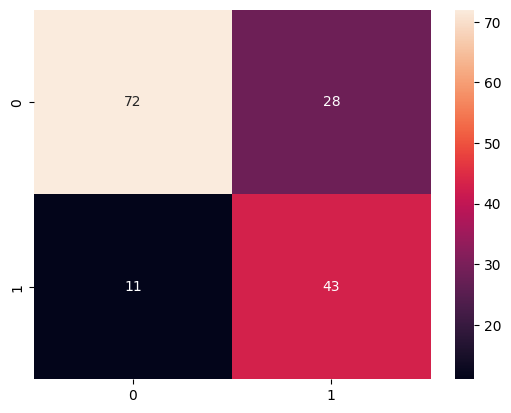

In [184]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

In [17]:
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [ ]:
model.save("./indian_diabetes_ann.keras")

### Model Testing

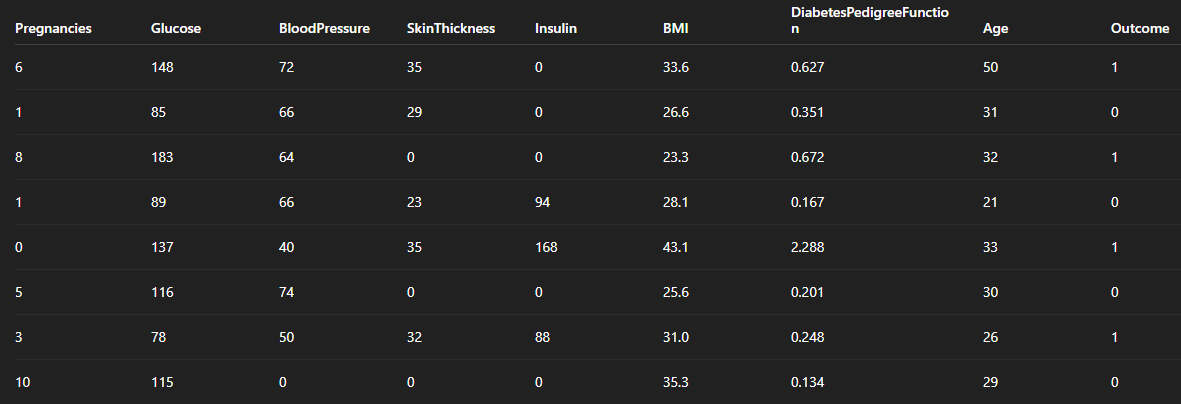

In [196]:
sample_input = [[6, 148, 72, 35, 0, 33.6, .627, 50]]
model.predict(scaler.transform(sample_input)) > 0.5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[ True]])

In [200]:
sample_input = [[5, 116, 74, 0, 0, 25.6, 0.20, 30]]
model.predict(scaler.transform(sample_input)) > 0.5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


array([[False]])